# Gauss-Newton vs. Levenberg-Marquardt

<div style="width: 100%; overflow: hidden;">
     <div style="width: 800px; float: left;">
         The Gauss-Newton Algorithm (GNA) and famous Levenberg-Marquardt Algorithm (LMA) are often utilized as a generic method for least-squares curve-fitting, which interactively demonstrated and compared with each other in this notebook. For GNA and LMA implementation, a numerical approximation of the Jacobian is employed in this example.
         <img src="./img/lm-fit_anim.gif" style="width:450px;text-align:left;vertical-align: middle;"/>
         last update: 14/11/2020
     </div>
     <div style="margin-left: 820px;">
        <b>Author</b><br><br>
        <a href='http://www.christopherhahne.de', style="text-decoration: None; text-align: left;">
            <img align="left" src="http://www.christopherhahne.de/images/about.jpg" width="78"/>
            <br><br><br><br><br><br>
            <b>Christopher<br>Hahne, PhD</b>
        </a>
    </div>
</div>

## Model
For a parametric fit, we choose a function model $M(\mathbf{p};x)$, which may be of the form

$$
M(\mathbf{p};x)=M(a, \mu, \sigma, \lambda; x)=
\frac{a}{\sigma\sqrt{2\pi}} e^{\frac{-\left(x-\mu\right)^2}{2\sigma^2}} \left(1 + \text{erf}\left(\lambda\frac{x-\mu}{\sigma\sqrt{2}}\right)\right)
$$

with $\text{erf}(\cdot)$ as the [error function](https://en.wikipedia.org/wiki/Error_function) and $\mathbf{p}=(a, \mu, \sigma, \lambda)$ as the fit coefficients.

In [1]:
import numpy as np
from scipy.special import erf

def asym_gaussian(p, x=0):
    """
    Asymmetric Gaussian function model
    """
    amp = p[0] / (p[2] * np.sqrt(2 * np.pi))
    spread = np.exp((-(x - p[1]) ** 2.0) / (2 * p[2] ** 2.0))
    skew = 1 + erf((p[3] * (x - p[1])) / (p[2] * np.sqrt(2)))
    return amp * spread * skew

## Generation of synthetic data

<IPython.core.display.Javascript object>


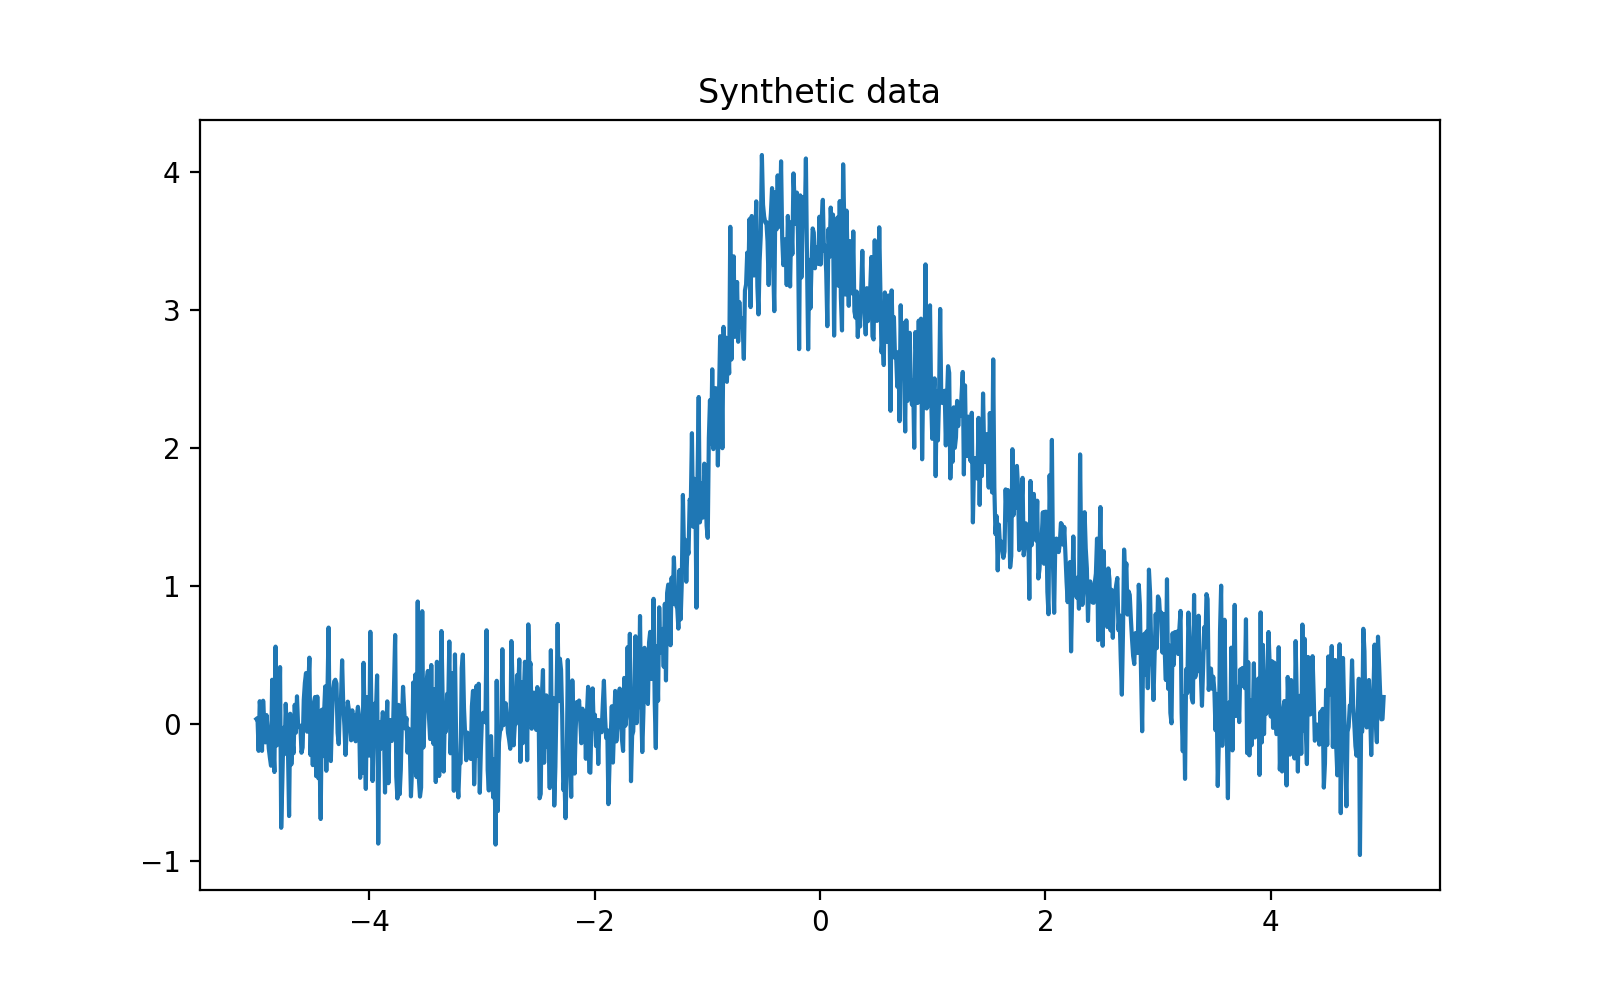

In [2]:
x = np.linspace(-5, 5, 1000)
norm, mean, sigm, skew = 10, -1, 2, 5
data = asym_gaussian([norm, mean, sigm, skew], x)
data_raw = data + .3 * np.random.randn(len(x))

%matplotlib notebook
%matplotlib notebook
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.title('Synthetic data')
plt.plot(x, data_raw, label='raw signal')

## Cost function
For minimization, we define the objective function $\mathbf{f}(\mathbf{p})$ to be

$$\mathbf{f}(\mathbf{p})=f_i(\mathbf{p})=y_i−M(\mathbf{p};x_i)$$

which is written as

In [3]:
residuals = lambda p, y, x: y - asym_gaussian(p, x)

## Numerical Jacobian
As opposed to the analytically derived Jacobian $\mathbf{J}$, a multi-variate numerical approximate $\mathbf{\tilde{J}}(\mathbf{p})\approx \mathbf{J}$ via $\mathbf{p}$ and the functor $\mathbf{f}(\cdot)$ is provided hereafter.

In [4]:
def jacobian_approx(p, f, dp=1e-8, args=()):
    """
    Numerical approximation for the multivariate Jacobian
    :param p: initial value(s)
    :param f: function handle
    :param dp: delta p for approximation
    :param args: additional arguments passed to function handle
    :return: jacobian
    """
    n = len(p)
    jac = np.zeros(n) if len(args) == 0 else np.zeros([n, len(args[0])])
    for j in range(n):  # through columns to allow for vector addition
        dpj = abs(p[j]) * dp if p[j] != 0 else dp
        p_plus = [(pi if k != j else pi + dpj) for k, pi in enumerate(p)]
        # compute jacobian while passing optional arguments
        jac[j] = (f(*((p_plus,) + args)) - f(*((p,) + args))) / dpj

    return jac if len(args) == 0 else jac.T

## Gauss-Newton Algorithm (GNA)
From the numerical estimate of a Jacobian, we can further compute a multivariate gradient $\mathbf{g}$ from $\mathbf{J}$ and cost function $\mathbf{f}$ using

$$\mathbf{g}=\mathbf{J}^\intercal \mathbf{f}$$

Similary, the Hessian can be approximated via

$$\mathbf{H}\approx\mathbf{J}^\intercal \mathbf{J}$$

which then allows to replace the first- and second-order derivatives of the conventional Newton method so that

$$\mathbf{h}_{gn} = −(\mathbf{J}^\intercal\mathbf{J})^{-1}\mathbf{J}^\intercal \mathbf{f}$$

where $\mathbf{h}_{gn}$ denotes the *Gauss-Newton step*. This is used in the iterative update which is accomplished via

$$\mathbf{p}_{k+1}=\mathbf{p}_k+\alpha\mathbf{h}_{gn}$$

with $\alpha$ acting as the parameter representing the learning rate.

In [5]:
def lsq_gna(p, functor, args=(), l=.1, tol=1e-14, max_iter=500):
    """
    Gauss-Newton implementation
    :param p: initial value(s)
    :param functor: user-provided function which takes p (and additional arguments) as input
    :param args: optional arguments passed to functor
    :param l: learning rate
    :param tol: tolerance for stop condition
    :param max_iter: maximum number of iterations
    :return: list of results, eps
    """
    j = jacobian_approx(p, functor, args=args)
    g = np.dot(j.T, functor(*((p,) + args))) if len(args) != 0 else np.dot(j.T, functor(p))
    H = np.dot(j.T, j)
    eps = 1
    p_list = []
    while len(p_list) < max_iter:
        h = -l*np.dot(np.linalg.inv(H), g)
        p += h
        p_list.append(p.copy())
        j = jacobian_approx(p, functor, args=args)
        g = np.dot(j.T, functor(*((p,) + args))) if len(args) != 0 else np.dot(j.T, functor(p))
        H = np.dot(j.T, j)
        eps = max(abs(g))
        if eps < tol:
            break
    return p_list, eps

## Levenberg-Marquardt Algorithm (LMA)
Next, we employ the LMA as a gradual blend of the Gauss-Newton and Gradient Descent method. The main motivation for LMA is to automatically fade between the two in an optimal way. To achieve this, Levenberg and Marquardt introduced the term $\mu\mathbf{D}$ to the *Gauss-Newton step* as seen in

$$\newcommand{\diag}{\mathop{\mathrm{diag}}}
\mathbf{h}_{lm} = −(\mathbf{H}+\mu\mathbf{D})^{-1}\mathbf{g}$$

or respectively

$$\newcommand{\diag}{\mathop{\mathrm{diag}}}
\mathbf{h}_{lm} = −(\mathbf{J}^\intercal\mathbf{J}+\mu\mathbf{D})^{-1}\mathbf{J}^\intercal \mathbf{f}$$

where $\mathbf{D}$ is a diagonal matrix and $\mu\ge0$ is the damping parameter, which shifts between the influence of the Gradient Descent and Gauss-Newton method. In practice, $\mu$ is reduced following an update which decreases the error so that $\mathbf{h}_{lm} \approx \mathbf{h}_{gn}$ and $\mu$ is increased once the error goes up. More precisely, Levenberg initially proposed to use an identity matrix $\mathbf{I}$ that scales with $\mu$ so that $\mathbf{D}:=\mathbf{I}$. For the initialization of $\mu$, Levenberg used

$$\mu_0 = \tau \max\{\diag{[\mathbf{J}^\intercal\mathbf{J}]}\}$$

where $\tau$ is set by the user. Then $\mu_k$ is regularily updated on each iteration $k$ by

$$\mu_{k+1} = \mu_k \max\{1/3,1−(2\rho_k−1)^3\}$$

with $\rho_k$ acting as the *gain ratio* given by

$$\rho_k = \frac{\mathbf{f}(\mathbf{p}_k)-\mathbf{f}(\mathbf{p}_k+\mathbf{h}_{lm})}{L(\mathbf{0})-L(\mathbf{h}_{lm})}$$

where the denominator is predicted by

$$L(\mathbf{0})−L(\mathbf{h}_{lm}) = −\mathbf{h}_{lm}^\intercal \mathbf{J}^\intercal \mathbf{f}−\frac{1}{2}\mathbf{h}_{lm}^\intercal \mathbf{J}^\intercal \mathbf{J}\mathbf{h}_{lm}$$

After substituting $\mathbf{g}$ for $\mathbf{J}^\intercal \mathbf{f}$ and placing $-\frac{1}{2}\mathbf{h}_{lm}^\intercal$ outside the brackets, this may be written as

$$L(\mathbf{0})−L(\mathbf{h}_{lm}) = -\frac{1}{2}\mathbf{h}_{lm}^\intercal (\mathbf{2}\mathbf{g}+(\mathbf{J}^\intercal\mathbf{J}+\mu\mathbf{D}-\mu\mathbf{D})\mathbf{h}_{lm})$$

Since $\mathbf{J}^\intercal\mathbf{J}+\mu\mathbf{D} = -\mathbf{g}$ by definition of LMA, this becomes

$$L(\mathbf{0})−L(\mathbf{h}_{lm}) = \frac{1}{2}\mathbf{h}_{lm}^\intercal (\mu\mathbf{h}_{lm}-\mathbf{g})$$

after rearranging.

Later, Marquardt suggested to replace the identity matrix with the diagonal of the Hessian resulting in
$\newcommand{\diag}{\mathop{\mathrm{diag}}}\mathbf{D}:=\diag{[\mathbf{J}^\intercal\mathbf{J}]}$. There exist alternatives of this approach including $\mathbf{D}_k:=\max\{\diag{[\mathbf{J}^\intercal\mathbf{J}]}, \mathbf{D}_{k-1}\}$. Updates on $\mu_k$ have also been modified by Marquardt as follows

$$\mu_k = \mu_k\beta \quad \text{if} \, \rho_k < \rho_1 \\
\mu_k = \mu_k/\gamma \quad \text{if} \, \rho_k > \rho_2$$

where $\rho_1=0.25$ and $\rho_2=0.75$ represent thresholds for the *gain ratio* controlling the increase from $\beta=2$ and decrease via $\gamma=3$ as user-defined parameters.

All of the above-mentioned methodological solutions have the update procedure in common, which simplifies to

$$\mathbf{p}_{k+1}=\mathbf{p}_k+\mathbf{h}_{lm}$$

A full implementation of the LMA is provided below.

In [6]:
def lsq_lma(p, functor, args=(), tol=1e-14, tau=1e-3, meth='lev', rho1=.25, rho2=.75, bet=2, gam=3, max_iter=500):
    """
    Levenberg-Marquardt implementation for least-squares fitting of non-linear functions
    :param p: initial value(s)
    :param functor: user-provided function which takes p (and additional arguments) as input
    :param args: optional arguments passed to functor
    :param tol: tolerance for stop condition
    :param tau: factor to initialize damping parameter
    :param meth: method which is default 'lev' for Levenberg and otherwise Marquardt
    :param rho1: first gain factor threshold for damping parameter adjustment for Marquardt
    :param rho2: second gain factor threshold for damping parameter adjustment for Marquardt
    :param bet: multiplier for damping parameter adjustment for Marquardt
    :param gam: divisor for damping parameter adjustment for Marquardt
    :param max_iter: maximum number of iterations
    :return: list of results, eps
    """
    j = jacobian_approx(p, functor, args=args)
    g = np.dot(j.T, functor(*((p,) + args))) if len(args) != 0 else np.dot(j.T, functor(p))
    H = np.dot(j.T, j)
    u = tau * np.max(np.diag(H.diagonal()))
    v = 2
    eps = 1
    p_list = []
    while len(p_list) < max_iter:
        D = np.identity(j.shape[1])
        D *= 1 if meth == 'lev' else np.max(np.maximum(H.diagonal(), D.diagonal()))
        h = -np.dot(np.linalg.inv(H+u*D), g)
        f = functor(*((p,) + args)) if len(args) != 0 else functor(p)
        f_plus = functor(*((p+h,) + args)) if len(args) != 0 else functor(p+h)
        rho = (np.dot(f.T, f) - np.dot(f_plus.T, f_plus)) / np.dot(.5*h.T, u*h-g)
        if rho > 0:
            p += h
            p_list.append(p.copy())
            j = jacobian_approx(p, functor, args=args)
            g = np.dot(j.T, functor(*((p,) + args))) if len(args) != 0 else np.dot(j.T, functor(p))
            H = np.dot(j.T, j)
        if meth== 'lev':
            u, v = (u*np.max([1/3, 1-(2*rho-1)**3]), 2) if rho > 0 else (u*v, v*2)
        else:
            u = u*bet if rho < rho1 else u/gam if rho > rho2 else u
        eps = max(abs(g))
        if eps < tol:
            break
    return p_list, eps

In [7]:
initials = [.5, .5, .5, .5]
coeffs_gn, eps_gn = lsq_gna(initials, residuals, args=(data, x), l=.01)
coeffs_lm, eps_lm = lsq_lma(initials, residuals, args=(data, x), meth='marq')
print('GNA: %s with an error of %s after %s iterations.' % (coeffs_gn[-1], round(eps_gn,9), len(coeffs_gn)))
print('LMA: %s with an error of %s after %s iterations.' % (coeffs_lm[-1], round(eps_lm,9), len(coeffs_lm)))

GNA: [ 9.92454973 -1.00312649  1.99549491  4.99605561] with an error of 5.927967795 after 500 iterations.
LMA: [10. -1.  2.  5.] with an error of 0.0 after 18 iterations.


## Illustration of the result

The animation below indicates the optimization process with intermediate results from the iterative LMA procedure.

<IPython.core.display.Javascript object>


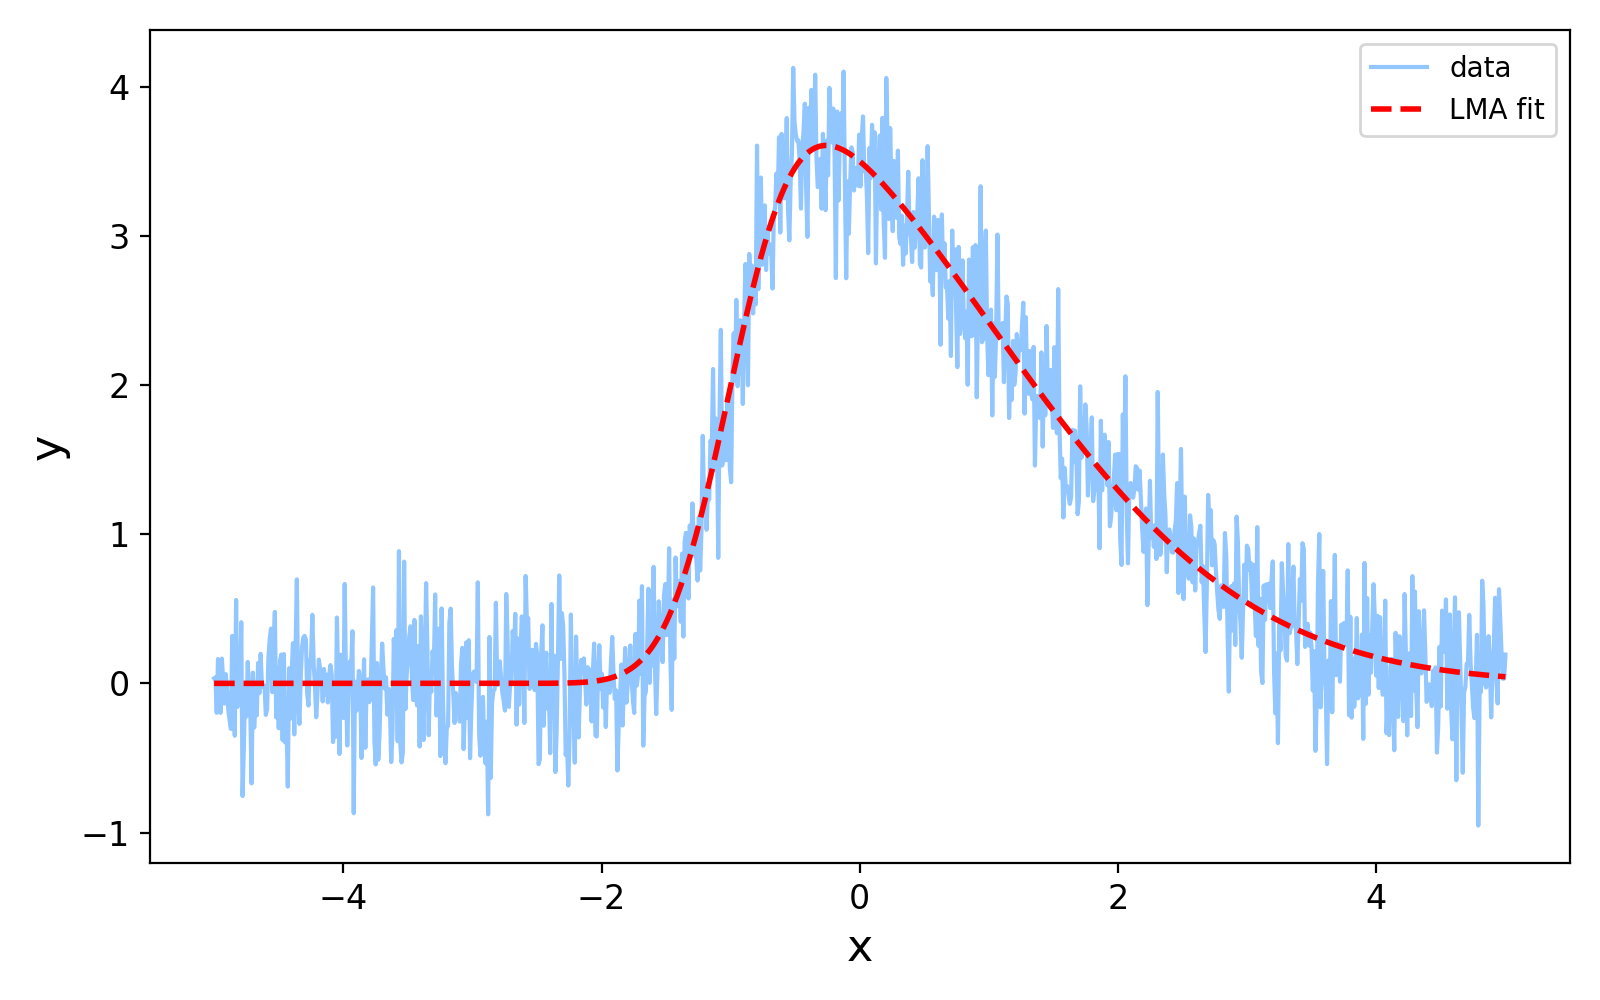

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt
plt.style.use('seaborn-pastel')

fig, ax = plt.figure(figsize=(8, 5)), plt.axes()
ax.plot(x, data_raw, label='data')
ax.set_xlabel('x', fontsize=16)
ax.set_ylabel('y', fontsize=16)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
line, = ax.plot([], [], '--', color='red', lw=2, label='LMA fit')
ax.legend()
plt.tight_layout()

def init():
    line.set_data([], [])
    return line,

def animate(i):
    y_res = asym_gaussian(coeffs_lm[i], x)
    line.set_data(x, y_res)
    return line,

anim = FuncAnimation(fig, animate, init_func=init, frames=len(coeffs_lm), interval=50, repeat=True)

# file styles
if False:
    import matplotlib as mpl
    mpl.rcParams['savefig.facecolor'] = '#148ec8'
    fig.set_facecolor('#148ec8')
    ax.set_facecolor('#148ec8')
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.tick_params(colors='white')
    HTML(anim.to_jshtml())
    anim.save('./data/lm-fit_anim.gif', writer='imagemagick', fps=5)

## Equivalent Scipy implementation
For ease of use, an equivalent of the above implementation is provided hereafter using [Scipy's leastsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.leastsq.html).

[ 9.99368467 -1.00982775  2.02698213  5.38112505]


<IPython.core.display.Javascript object>


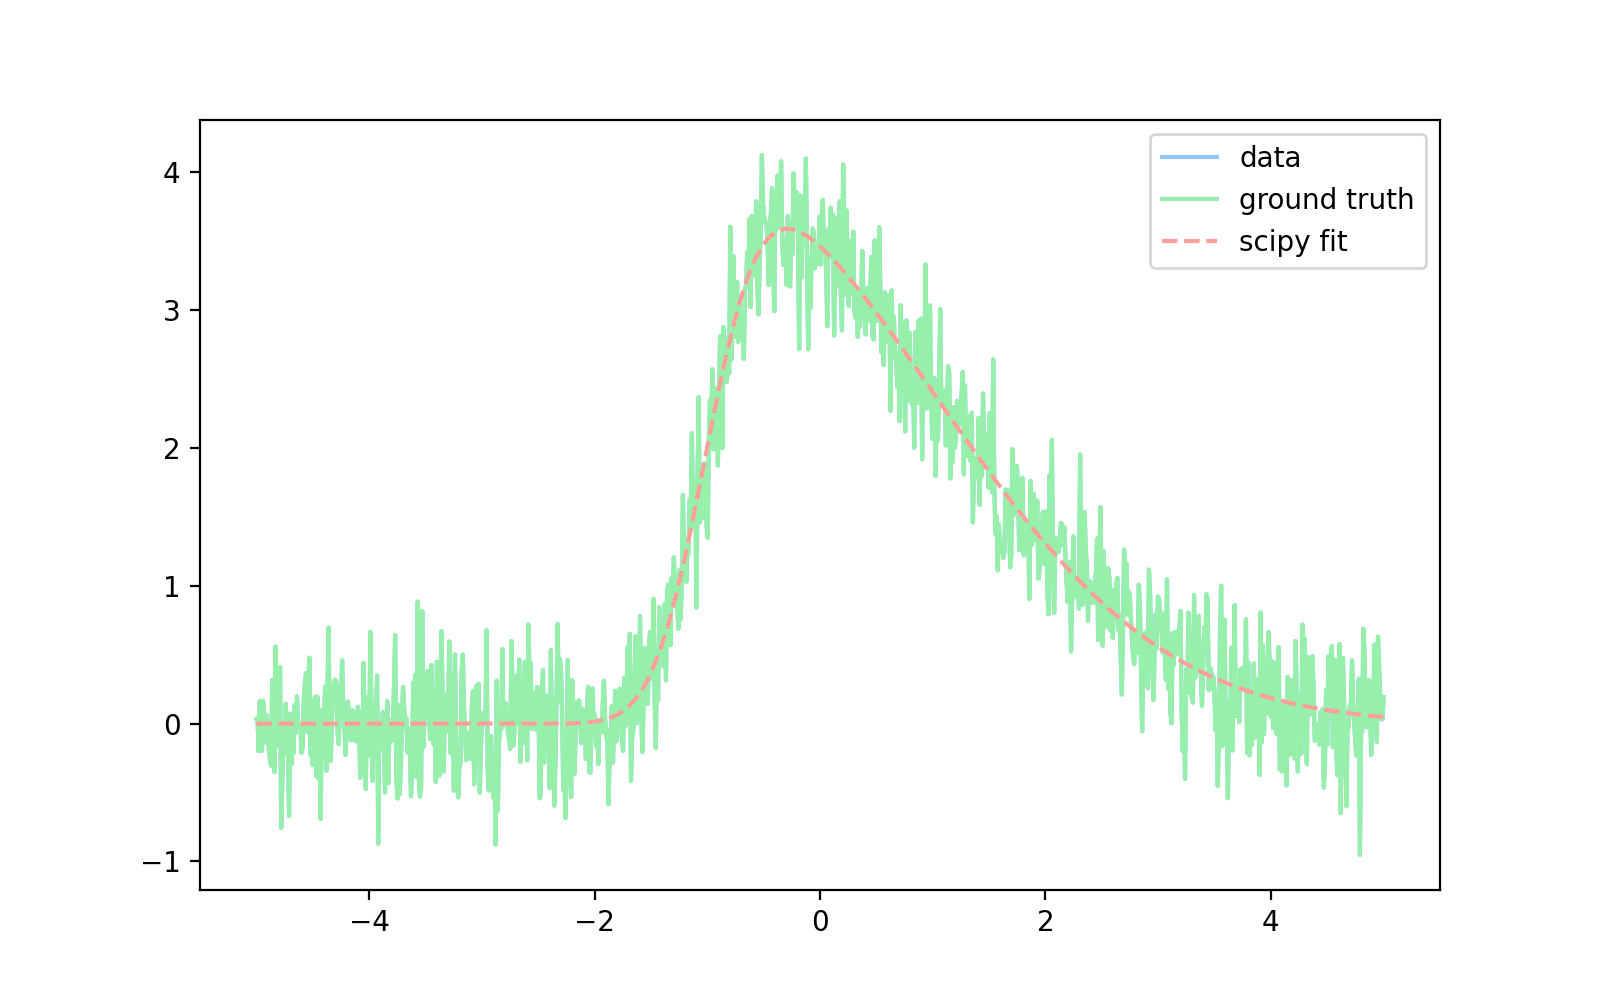

In [9]:
from scipy.optimize import leastsq

residuals = lambda p, y, x: y - asym_gaussian(p, x)

# executes least-squares regression analysis to optimize initial parameters
coeffs_scipy, _ = leastsq(residuals, initials, args=(data_raw, x))

print(coeffs_scipy)

y_scipy = asym_gaussian(coeffs_scipy, x)

plt.figure(figsize=(8, 5))
plt.plot(x, data_raw, label='data')
plt.plot(x, data_raw, label='ground truth')
plt.plot(x, y_scipy, linestyle='--', label='scipy fit')
plt.legend()